# Domain 4 — Vaccine Hesitancy & Demand-Side Behavioural Modelling
### Nigeria Immunization Modelling Framework · NPHCDA / UNICEF / GAVI

**Research question.** *To what extent is vaccine hesitancy contributing to coverage
shortfalls, and how do hesitancy patterns vary across states and population groups?*

**Hypothesis.** Confidence-based hesitancy (vaccine-safety fears, fertility myths,
conspiracy/misinformation) is the dominant demand-side construct, and its geography is
**distinct** from the supply-/access-side geography of zero-dose. If true, a single national
demand-generation message will be mis-targeted.

**Primary data.** `acsm_cleaned.xlsx` — the NPHCDA Advocacy, Communication & Social
Mobilisation (ACSM) monitoring register: **2,593 field activities, 36 states, Sep 2024–Oct 2026**,
exported from a KOBO/ODK instrument (139 fields). Each record is a community/advocacy/media
activity in which caregivers raised **questions** and **rumours**, coded into a fixed concern
taxonomy.

**Methodological contribution of this notebook.**
1. A transparent, reproducible **Composite Hesitancy Index (CHI)** built from the field-coded
   concern taxonomy, weighted by construct severity and **normalised by activity volume** so that
   high-activity states (e.g. Lagos) are not mechanically ranked highest.
2. **Reliability filtering** + non-parametric **bootstrap 95% confidence intervals** on every
   state estimate — small-sample states are flagged, not silently ranked.
3. A formal mapping of the field taxonomy onto the **WHO SAGE "3Cs"** framework
   (Confidence / Complacency / Convenience).
4. A **hesitancy-vs-access decoupling test** that cross-references the CHI against the
   project's authoritative **WHO/GAVI zero-dose estimates** — the DTP1-based Bayesian hierarchical
   forecast (NDHS 2008–2024 → 2026, with Getis-Ord Gi\* cluster classes and absolute child-burden) —
   to test the central hypothesis.

All figures are written to `figures/` and all tables to `tables/` as both `.csv` and a single
formatted `.xlsx` workbook. The notebook runs top-to-bottom with no manual steps.

---

## 0 · Environment, reproducibility & the publication theme

We pin a single random seed (used by the bootstrap), define the file paths with fall-backs so the
notebook runs unchanged in Colab, locally, or in the delivery sandbox, and install a custom
Matplotlib theme that gives every figure a consistent editorial look: a clean sans-serif face,
de-cluttered spines, hairline gridlines, and a reusable `figtitle()` helper that lays down a bold
title, a grey deck/subtitle, and a source footnote in the style used by *The Lancet Global Health*
and journal supplementary figures.

> **Running in Google Colab.** No manual setup is needed. The loader searches common paths first; if
> the ACSM file is not on disk it opens Colab's **upload widget** automatically
> (`google.colab.files`) — when prompted, upload **`acsm_cleaned.csv`** (or `.xlsx`). The reader
> accepts CSV or Excel and auto-detects non-UTF-8 encodings (Excel often exports CSVs as
> Windows-1252). The **zero-dose forecast dataset is embedded in the notebook** (§1), so you do **not**
> need to upload it — though dropping `state_zero_dose_forecast_ranked.csv` beside the notebook will
> transparently override the embedded copy with an updated one.

In [1]:
import os, sys, json, textwrap, warnings, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from matplotlib.patches import Patch
import matplotlib.font_manager as fm
from scipy import stats

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(20260528)        # single seed for the whole notebook
N_BOOT = 5000                                 # bootstrap resamples
MIN_ACTIVITIES = 10                           # reliability threshold for state ranking

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# ---- environment detection ----------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules

def _find(cands):
    for p in cands:
        try:
            if Path(p).exists():
                return Path(p)
        except Exception:
            pass
    return None

def locate_or_upload(cands, label, exts=(".csv", ".xlsx", ".xlsm", ".xls")):
    'Find a data file across candidate paths; in Colab, prompt upload if missing.'
    p = _find(cands)
    if p is not None:
        return p
    if IN_COLAB:
        from google.colab import files                      # noqa
        print(f"⬆  {label} not found — please choose it from your computer:")
        uploaded = files.upload()                            # writes files into the cwd
        for name in uploaded:                                # return the first matching upload
            if name.lower().endswith(exts):
                return Path(name)
    raise FileNotFoundError(
        f"{label} not found. Upload it (Colab) or place it beside the notebook.")

def read_tabular(path):
    'Read .csv or Excel transparently (handles non-UTF-8 CSV exports from Excel).'
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xlsm", ".xls"):
        return pd.read_excel(path, sheet_name=0)
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", engine="python")  # last-resort

# ---- locate the ACSM data file (CSV or XLSX; Colab upload fallback) ------------------
CANDIDATES = [
    Path("acsm_cleaned.csv"),  Path("acsm_cleaned.xlsx"),
    Path("/mnt/user-data/outputs/domain4_hesitancy/acsm_cleaned.xlsx"),
    Path("/mnt/user-data/uploads/acsm_cleaned.csv"),
    Path("/mnt/user-data/uploads/acsm_cleaned.xlsx"),
    Path.home() / "acsm_cleaned.csv",  Path.home() / "acsm_cleaned.xlsx",
]
DATA_PATH = locate_or_upload(CANDIDATES, "ACSM register (acsm_cleaned.csv or .xlsx)")

# ---- output directory (Colab-friendly) ----------------------------------------------
OUT = Path("/mnt/user-data/outputs/domain4_hesitancy") \
      if Path("/mnt/user-data/outputs").exists() else Path("outputs_domain4")
FIG = OUT / "figures"; TAB = OUT / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
print("Environment :", "Google Colab" if IN_COLAB else "local / sandbox")
print("Data        :", DATA_PATH)
print("Outputs     :", OUT)

⬆  ACSM register (acsm_cleaned.csv or .xlsx) not found — please choose it from your computer:


Saving acsm_cleaned.csv to acsm_cleaned.csv
Environment : Google Colab
Data        : acsm_cleaned.csv
Outputs     : outputs_domain4


In [2]:
# ----------------------------- PUBLICATION THEME --------------------------------------
FONT = "DejaVu Sans"
INK      = "#1d2733"   # near-black text
SUBINK   = "#5b6b7b"   # grey decks / source notes
GRID     = "#e3e8ee"
PANEL    = "#ffffff"

# Semantic palette — WHO 3Cs constructs
C_CONF   = "#c0392b"   # Confidence  (safety / fertility / conspiracy) — red family
C_CONV   = "#2471a3"   # Convenience (access / logistics)             — blue
C_COMPL  = "#7f8c8d"   # Complacency (no felt need)                   — grey
C_POL    = "#8e44ad"   # Political / governance                       — purple
C_OTHER  = "#bdc3c7"   # Other / uncoded                              — light grey
C_ACCENT = "#1f9e89"   # teal accent (matches the project deck)

# Concern-type ramp (severity-ordered, confidence family)
RAMP_CONF = ["#7b1d12", "#c0392b", "#e0644f", "#f0a08e"]
# Six geopolitical zones
ZONE_COLORS = {
    "NW": "#b3331f", "NE": "#dd7a2e", "NC": "#e6b800",
    "SW": "#1f9e89", "SE": "#2471a3", "SS": "#5b4b8a",
}

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "figure.facecolor": PANEL,
    "savefig.facecolor": PANEL, "savefig.bbox": "tight",
    "font.family": FONT, "font.size": 11, "text.color": INK,
    "axes.facecolor": PANEL, "axes.edgecolor": "#c7d0d9", "axes.linewidth": 0.9,
    "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.grid": True, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.9,
    "xtick.color": SUBINK, "ytick.color": SUBINK,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
})

def figtitle(fig, title, deck=None, source=None, x=0.012):
    'Editorial title block: bold title, grey deck, source footnote.'
    fig.text(x, 0.992, title, ha="left", va="top", fontsize=15.5,
             fontweight="bold", color=INK)
    if deck:
        fig.text(x, 0.945, deck, ha="left", va="top", fontsize=10.8,
                 color=SUBINK)
    if source:
        fig.text(x, 0.006, source, ha="left", va="bottom", fontsize=8.2,
                 color=SUBINK, style="italic")

def save(fig, name):
    p = FIG / name
    fig.savefig(p, dpi=220); fig.savefig(p.with_suffix(".pdf"))
    print("saved →", p.name, "(+pdf)")
    return p

SRC = "Source: NPHCDA ACSM monitoring register (acsm_cleaned.xlsx), 2,593 activities, 36 states. Analysis: Domain 4, NPHCDA/UNICEF Immunization Modelling Framework."
print("Theme loaded.")

Theme loaded.


## 1 · Reference layer — the authoritative zero-dose definition & forecast

To answer *"to what extent is hesitancy contributing to coverage shortfalls"* we must define the
coverage shortfall precisely and measure it with the project's authoritative numbers — **not** a
proxy. Both are taken directly from the NPHCDA / UNICEF zero-dose modelling deliverable
(`state_zero_dose_forecast_ranked.csv`, `zero_dose_analysis5.ipynb`).

### Zero-dose definition (WHO / GAVI) — used verbatim
> **A zero-dose child is a child aged 12–23 months who has not received DTP1 (Pentavalent dose 1)
> by the end of their first year of life, even if they received birth-dose vaccines (BCG, OPV0,
> HepB0).**
> *Reference: WHO IMR-7792; GAVI Phase 5 Equity Goal.*

DTP1 (the first pentavalent dose) is the standard marker of *contact with the routine system*;
failure to receive it is the operational signature of a child the system never reached.

### Source of the zero-dose estimates attached here
The per-state values are the posterior output of a **Bayesian Hierarchical Beta Regression** fit to
NDHS zero-dose at survey years **2008 / 2013 / 2018 / 2024**, with a DHIS2 trend covariate, producing
**posterior-predictive forecasts for 2026–2028** with 95 % credible intervals, plus **Getis-Ord Gi\***
spatial-cluster classification (GRID3 boundaries, 999 permutations) and a composite **risk index →
priority tier** (Tier 1 Critical … Tier 4 Lower). Sampler NUTS, all chains converged
(`r̂ = 1.00`). We therefore carry, for every state: the observed 2024 value, the 2026 forecast (mean
+ CI), the absolute 2026 zero-dose **child count**, the Gi\* class, and the priority tier.

This replaces the archetype-mean proxy used in earlier drafts of this notebook and lets the
hesitancy–coverage cross-analysis run against the real, definition-correct burden.

> **Self-contained:** the full 37-state × 32-column forecast table is **embedded in the next cell as
> base64**, so the notebook reproduces every zero-dose figure with no external file. Place
> `state_zero_dose_forecast_ranked.csv` beside the notebook to override the embedded copy.

In [3]:
import pandas as pd, numpy as np
# ---- six geopolitical zones (canonical) ----------------------------------------------
ZONES = {
 "NW": ["jigawa","kaduna","kano","katsina","kebbi","sokoto","zamfara"],
 "NE": ["adamawa","bauchi","borno","gombe","taraba","yobe"],
 "NC": ["benue","fct","kogi","kwara","nasarawa","niger","plateau"],
 "SW": ["ekiti","lagos","ogun","ondo","osun","oyo"],
 "SE": ["abia","anambra","ebonyi","enugu","imo"],
 "SS": ["akwa ibom","bayelsa","cross river","delta","edo","rivers"],
}
STATE_ZONE = {s: z for z, ss in ZONES.items() for s in ss}
ZONE_FULL2ABBR = {"north west":"NW","north east":"NE","north central":"NC",
                  "south west":"SW","south east":"SE","south south":"SS"}

# ---- load the authoritative Bayesian zero-dose forecast ------------------------------
# The dataset is EMBEDDED below (base64) so the notebook is self-contained — no second
# upload is needed in Colab. If an external CSV is present it transparently overrides
# the embedded copy (so you can drop in an updated forecast without editing the notebook).
import base64, io
_ZD_B64 = "..."
ZD_CANDS = [Path("state_zero_dose_forecast_ranked.csv"),
            OUT/"state_zero_dose_forecast_ranked.csv",
            Path("/mnt/user-data/outputs/domain4_hesitancy/state_zero_dose_forecast_ranked.csv"),
            Path("/mnt/user-data/uploads/state_zero_dose_forecast_ranked.csv"),
            Path.home()/"state_zero_dose_forecast_ranked.csv"]
_ext = _find(ZD_CANDS)
if _ext is not None:
    zd = pd.read_csv(_ext); _zd_source = f"external file ({_ext.name})"
else:
    zd = pd.read_csv(io.StringIO(base64.b64decode(_ZD_B64).decode("utf-8")))
    _zd_source = "embedded copy (base64, built into the notebook)"
zd["state"] = zd["state"].str.strip().str.lower()
zd["zone_abbr"] = zd["zone"].str.strip().str.lower().map(ZONE_FULL2ABBR)

def zd_tier_pct(v):   # framework prevalence tiers (for description only)
    if pd.isna(v): return "Unknown"
    return "Critical" if v>=50 else "High" if v>=25 else "Moderate" if v>=10 else "Low"

ref = (zd.rename(columns={"zd_obs_2024":"zd_obs2024",
                          "zd_pred_2026_mean":"zd_pred2026",
                          "zd_pred_2026_lo95":"zd_lo2026",
                          "zd_pred_2026_hi95":"zd_hi2026",
                          "zd_count_2026":"zd_count2026",
                          "gi_class_2026":"gi_class",
                          "priority_tier":"tier"})
         [["state","zone_abbr","zd_obs2024","zd_pred2026","zd_lo2026","zd_hi2026",
           "zd_count2026","gi_class","tier","risk_index"]]
         .rename(columns={"zone_abbr":"zone"}))
# zd_ref = the definition-correct 2026 forecast prevalence (headline coverage-shortfall measure)
ref["zd_ref"]  = ref["zd_pred2026"]
ref["zd_tier"] = ref["zd_pred2026"].apply(zd_tier_pct)
ref["gi_simple"] = np.where(ref["gi_class"].str.contains("Hot"),"Hot spot",
                    np.where(ref["gi_class"].str.contains("Cold"),"Cold spot","Not significant"))
print(f"Zero-dose reference: {len(ref)} states | source: {_zd_source}")
print(f"National 2026 zero-dose burden (sum of state counts): "
      f"{ref['zd_count2026'].sum():,.0f} children")
print("Priority-tier distribution:", dict(ref['tier'].value_counts()))
ref.head()

Zero-dose reference: 37 states | source: embedded copy (base64, built into the notebook)
National 2026 zero-dose burden (sum of state counts): 2,070,369 children
Priority-tier distribution: {'Tier 4: Lower': np.int64(16), 'Tier 3: Moderate': np.int64(14), 'Tier 2: High': np.int64(4), 'Tier 1: Critical': np.int64(3)}


,state,zone,zd_obs2024,zd_pred2026,zd_lo2026,zd_hi2026,zd_count2026,gi_class,tier,risk_index,zd_ref,zd_tier,gi_simple
0,sokoto,NW,86.5,71.902291,57.947615,83.861991,168836.646689,Hot Spot (p<0.01),Tier 1: Critical,85.220477,71.902291,Critical,Hot spot
1,kebbi,NW,84.0,68.270106,53.469255,81.033191,154105.427921,Hot Spot (p<0.01),Tier 1: Critical,81.701209,68.270106,Critical,Hot spot
2,zamfara,NW,82.6,73.059812,59.735398,84.610285,156169.001580,Hot Spot (p<0.01),Tier 1: Critical,80.970530,73.059812,Critical,Hot spot
3,kano,NW,42.4,36.387900,26.690956,46.988565,194931.797055,Not Significant,Tier 2: High,61.068438,36.387900,High,Not significant
4,kaduna,NW,45.6,43.364699,30.288122,56.546509,138382.825416,Hot Spot (p<0.05),Tier 2: High,58.368883,43.364699,High,Hot spot


## 2 · Ingestion & provenance

The register is a wide KOBO export (139 columns). For Domain 4 the analytically meaningful
fields are a small, well-defined subset: the geography (`states`, `lgas`, `ward`, `admin_level`),
the activity descriptors (`activity_type`, `date_monitor`), the two **concern channels**
— *questions* asked and *rumours* circulating — and their fixed-taxonomy codes
(`type_questions`, `type_rumors`), plus the gender of who raised each concern.

In [4]:
raw = read_tabular(DATA_PATH)
print("Raw shape:", raw.shape)

KEEP = ["admin_level","states","lgas","ward","date_monitor","activity_type",
        "did_question","type_questions","did_rumor","type_rumors",
        "whoraisedquestions/male","whoraisedquestions/female",
        "whoraisedrumors/males","whoraisedrumors/females",
        "no_questions_persons","no_rumors_persons"]
df = raw[KEEP].copy()
df.columns = ["admin_level","state","lga","ward","date","activity_type",
              "did_q","type_q","did_r","type_r",
              "q_male","q_female","r_male","r_female","n_q","n_r"]
df.head(3)

Raw shape: (2593, 139)


,admin_level,state,lga,ward,date,activity_type,did_q,type_q,did_r,type_r,q_male,q_female,r_male,r_female,n_q,n_r
0,lga,adamawa,mayo-belwa,Mbilla,2025-09-02 00:00:00,sensitization_activities,NaN,NaN,NaN,NaN,2.458824,1.893428,1.246575,1.052133,3.985915,2.008772
1,lga,imo,aboh-mbaise,Ahiato,2025-08-18 00:00:00,sensitization_activities,NaN,NaN,NaN,NaN,2.458824,1.893428,1.246575,1.052133,3.985915,2.008772
2,lga,kwara,ilorin east,Oke oyi,2025-09-01 00:00:00,advocacy_mtgs_type,NaN,NaN,NaN,NaN,2.458824,1.893428,1.246575,1.052133,3.985915,2.008772


## 3 · Cleaning, data-quality audit & the imputation guard

Three cleaning decisions are made explicit because they materially affect the analysis and are the
kind of thing a reviewer will probe:

1. **State harmonisation.** Names are lower-cased and trimmed; six records with a missing state are
   dropped from state-level work but retained for national counts.
2. **Analysis window.** `date_monitor` is parsed; two stray records outside the operational window
   (one in 2024-09, one in 2026-10) are flagged. The substantive activity is the **Sep 2025 – Jan 2026
   measles–rubella mobilisation**.
3. **Imputation guard — the important one.** The supplied file was cleaned with **mean imputation**
   on the numeric person-count and gender fields: a single non-integer constant (e.g. `2.4588…` for
   male question-raisers) was written into every originally-missing cell. We **detect that constant
   automatically and mask it back to missing**, so all downstream gender/volume statistics use only
   genuinely-reported values. The categorical concern codes (`type_questions`, `type_rumors`) were
   **not** imputed and are used as the analytic backbone.

In [5]:
# --- harmonise text (plain object dtype + np.nan so boolean masks stay null-safe) ---
import numpy as np
def clean_cat(s):
    out = s.astype(str).str.strip().str.lower()
    return out.replace({"nan": np.nan, "<na>": np.nan, "none": np.nan, "": np.nan})
for c in ["state","lga","ward","activity_type","type_q","type_r","did_q","did_r"]:
    df[c] = clean_cat(df[c])

# --- parse dates & window flag ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["ym"]   = df["date"].dt.to_period("M")
WIN_LO, WIN_HI = pd.Timestamp("2025-06-01"), pd.Timestamp("2026-02-28")
df["in_window"] = df["date"].between(WIN_LO, WIN_HI)

# --- IMPUTATION GUARD: mask the mean-imputed constant back to NaN ---
def demask(col):
    s = df[col].astype(float)
    noninteger = s[(s % 1 != 0)]
    if len(noninteger):
        const = noninteger.mode().iloc[0]
        n = int((s == const).sum())
        df.loc[s == const, col] = np.nan
        return const, n
    return None, 0

import numpy as np
guard = {c: demask(c) for c in ["q_male","q_female","r_male","r_female","n_q","n_r"]}
guard_tbl = pd.DataFrame(
    [{"field":c,"imputed_constant":round(v[0],4) if v[0] else None,
      "cells_unmasked":v[1],"genuine_remaining":int(df[c].notna().sum())}
     for c,v in guard.items()])
print("Imputation guard report"); print(guard_tbl.to_string(index=False))

Imputation guard report
   field  imputed_constant  cells_unmasked  genuine_remaining
  q_male            2.4588            1403               1190
q_female            1.8934            1467               1126
  r_male            1.2466            2374                219
r_female            1.0521            2382                211
     n_q            3.9859            1386               1207
     n_r            2.0088            2365                228


In [6]:
# --- canonical concern taxonomy: harmonise the two channels onto one scheme -----------
Q_MAP = {"vaccine_safety_concern":"Safety","infertility_concerns":"Infertility",
         "conspirancy_theories":"Conspiracy","politically_inclined_rumours":"Political",
         "other_s":"Other"}
R_MAP = {"vaccine_safety_concerns":"Safety","infertility_concern":"Infertility",
         "conspirancy_theory":"Conspiracy","politically_inclined_rumour":"Political",
         "other":"Other"}
df["concern_q"] = df["type_q"].map(Q_MAP)
df["concern_r"] = df["type_r"].map(R_MAP)

# state-level analytic frame: only records with a valid mapped state
df["valid_state"] = df["state"].isin(STATE_ZONE.keys())
n_bad = (~df["valid_state"] & df["state"].notna()).sum()
print("Records:", len(df))
print("  with valid mapped state :", int(df["valid_state"].sum()))
print("  missing state           :", int(df["state"].isna().sum()))
print("  unmapped state label    :", int(n_bad),
      "->", df.loc[~df["valid_state"] & df["state"].notna(),"state"].unique()[:8])
df["zone"] = df["state"].map(STATE_ZONE)

Records: 2593
  with valid mapped state : 2587
  missing state           : 6
  unmapped state label    : 0 -> []


In [7]:
# --- QA snapshot table -----------------------------------------------------------------
qa = pd.Series({
 "Records (activities)": len(df),
 "States represented": df["state"].nunique(dropna=True),
 "LGAs represented": df["lga"].nunique(dropna=True),
 "Date range": f'{df["date"].min():%Y-%m-%d} → {df["date"].max():%Y-%m-%d}',
 "Months covered": int(df["ym"].nunique()),
 "Activities in core window (Jun25–Feb26)": int(df["in_window"].sum()),
 "Activities w/ ≥1 question raised": int((df["did_q"]=="yes").sum()),
 "Activities w/ ≥1 rumour raised": int((df["did_r"]=="yes").sum()),
 "Coded question-concerns": int(df["concern_q"].notna().sum()),
 "Coded rumour-concerns": int(df["concern_r"].notna().sum()),
})
qa_df = qa.rename("value").to_frame()
qa_df.to_csv(TAB/"table1_sample_profile.csv")
print(qa_df.to_string())

                                                           value
Records (activities)                                        2593
States represented                                            36
LGAs represented                                             336
Date range                               2024-09-12 → 2026-10-18
Months covered                                                12
Activities in core window (Jun25–Feb26)                     2590
Activities w/ ≥1 question raised                            1222
Activities w/ ≥1 rumour raised                               233
Coded question-concerns                                     1185
Coded rumour-concerns                                        224


## 4 · Measurement framework

### 4.1 Mapping the field taxonomy onto the WHO SAGE "3Cs"

Vaccine hesitancy is operationalised with the WHO SAGE Working Group **3Cs** model. The ACSM
register's five concern codes map cleanly onto these constructs, which lets us speak in the language
the global hypothesis is framed in:

| Field concern code | 3Cs construct | Demand/Supply side | Rationale |
|---|---|---|---|
| Vaccine safety | **Confidence** | Demand | Trust in vaccine safety / AEFI fear |
| Infertility / fertility myth | **Confidence** | Demand | Trust in product intent |
| Conspiracy / misinformation | **Confidence** | Demand | Trust in system & motives |
| Political / governance rumour | *Confidence (governance)* | Demand | Trust in authorities |
| Other / logistics / "no felt need" | **Convenience / Complacency** | Supply/mixed | Residual, largely operational |

The dominant, well-populated signal sits squarely in **Confidence**. This is the construct the
Composite Hesitancy Index is built to capture.

### 4.2 The Composite Hesitancy Index (CHI)

For state *s* the index is a **severity-weighted concern rate per activity**:

$$\mathrm{CHI}_s \;=\; \frac{0.40\,\text{Safety}_s \;+\; 0.35\,\text{Infertility}_s \;+\; 0.25\,\text{Conspiracy}_s}{N_s}\times 100$$

where the numerators are counts of *question-channel* concern codes and \(N_s\) is the number of
activities conducted in the state. Three design choices make this defensible:

* **Severity weights (0.40 / 0.35 / 0.25).** Safety fear is the most prevalent and most directly
  coverage-suppressing; fertility myths are highly "sticky" but rarer; conspiracy is corrosive but
  rarest. Weights sum to 1 so the index is interpretable as a weighted concern incidence.
* **Normalisation by \(N_s\).** Raw counts simply track field effort (Lagos ran 436 activities). The
  per-activity rate measures **how concern-dense the population is**, independent of how hard the
  state was canvassed — the quantity the research question actually asks about.
* **Question channel as the spine.** Questions are *actively raised by caregivers* (a direct
  hesitancy signal); rumours are analysed separately as a circulating-misinformation lens.

> The weights are a transparent prior, not a fitted parameter. Section 9 stress-tests the ranking
> against equal weights and a safety-only index to show the conclusions are weight-robust.

## 5 · National concern profile

Before any index, the raw epidemiology of what caregivers actually said. We tabulate the concern
taxonomy across the two channels (questions vs rumours) and quantify how widespread vaccine-safety
fear is relative to everything else.

In [8]:
# national inventory by channel
inv = pd.DataFrame({
    "Questions": df["concern_q"].value_counts(),
    "Rumours":   df["concern_r"].value_counts(),
}).fillna(0).astype(int)
order = ["Safety","Infertility","Conspiracy","Political","Other"]
inv = inv.reindex(order).fillna(0).astype(int)
inv["Total"] = inv["Questions"] + inv["Rumours"]
inv["% of coded questions"] = (inv["Questions"]/inv["Questions"].sum()*100).round(1)
n_q_act = int((df["did_q"]=="yes").sum())
act_with_safety = int((df["concern_q"]=="Safety").sum())
inv.to_csv(TAB/"table2_concern_inventory.csv")
print(inv.to_string())
print(f"\nVaccine-safety questions: {int(inv.loc['Safety','Questions'])} "
      f"({inv.loc['Safety','% of coded questions']}% of all coded questions)")
print(f"Activities raising ≥1 question: {n_q_act} of {len(df)} "
      f"({n_q_act/len(df)*100:.0f}% of all activities)")

             Questions  Rumours  Total  % of coded questions
Safety             710      108    818                  59.9
Infertility         79       63    142                   6.7
Conspiracy          45       22     67                   3.8
Political           22       13     35                   1.9
Other              329       18    347                  27.8

Vaccine-safety questions: 710 (59.9% of all coded questions)
Activities raising ≥1 question: 1222 of 2593 (47% of all activities)


### Figure 1 — The national concern taxonomy is overwhelmingly a *confidence* problem

A diverging two-channel bar: question-channel concerns to the right, rumour-channel to the left,
coloured by 3Cs construct. The visual carries the first headline — vaccine-safety fear dwarfs every
other concern in **both** channels.

saved → fig1_national_concern_taxonomy.png (+pdf)


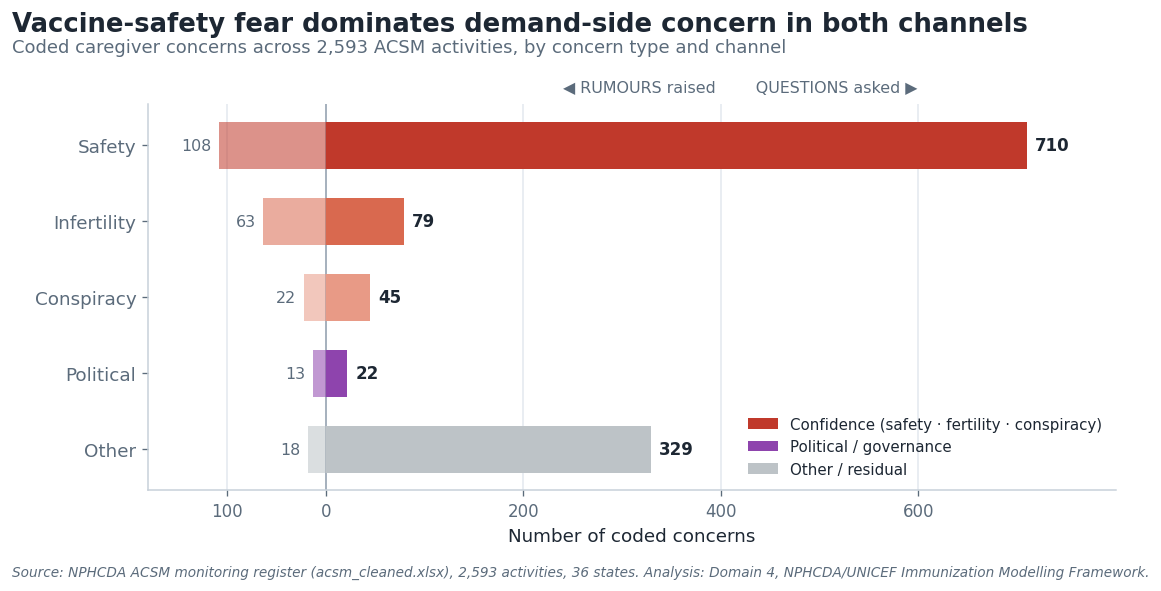

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))
cat = order
y = np.arange(len(cat))[::-1]
qv = inv["Questions"].values; rv = inv["Rumours"].values
cmap = {"Safety":C_CONF,"Infertility":"#d9694f","Conspiracy":"#e89a86",
        "Political":C_POL,"Other":C_OTHER}
cols = [cmap[c] for c in cat]
ax.barh(y, qv, color=cols, height=0.62, zorder=3)
ax.barh(y, -rv, color=cols, height=0.62, alpha=0.55, zorder=3)
for yi, q, r in zip(y, qv, rv):
    if q: ax.text(q+8, yi, f"{q}", va="center", ha="left", fontsize=10, color=INK, fontweight="bold")
    if r: ax.text(-r-8, yi, f"{r}", va="center", ha="right", fontsize=9.5, color=SUBINK)
ax.set_yticks(y); ax.set_yticklabels(cat, fontsize=11)
ax.axvline(0, color="#9aa7b4", lw=1.0)
ax.set_xlim(-180, 800)
ax.set_xticks([-100,0,200,400,600])
ax.set_xticklabels(["100","0","200","400","600"])
ax.text(420, len(cat)-0.3, "◀ RUMOURS raised        QUESTIONS asked ▶",
        fontsize=9.5, color=SUBINK, ha="center")
ax.grid(axis="y", visible=False)
ax.set_xlabel("Number of coded concerns")
leg = [Patch(fc=C_CONF, label="Confidence (safety · fertility · conspiracy)"),
       Patch(fc=C_POL, label="Political / governance"),
       Patch(fc=C_OTHER, label="Other / residual")]
ax.legend(handles=leg, loc="lower right", fontsize=9, ncol=1)
figtitle(fig,
  "Vaccine-safety fear dominates demand-side concern in both channels",
  "Coded caregiver concerns across 2,593 ACSM activities, by concern type and channel",
  SRC)
fig.subplots_adjust(top=0.83, bottom=0.16, left=0.13, right=0.97)
save(fig, "fig1_national_concern_taxonomy.png"); plt.show()

### Figure 2 — Concern surfaces in step with the mobilisation campaign

Monthly activity volume (bars) against the number of activities surfacing a safety concern (line).
This situates the data in time and shows that concern detection scales with — and is created by —
active community engagement during the Sep 2025–Jan 2026 measles–rubella push.

saved → fig2_temporal_profile.png (+pdf)


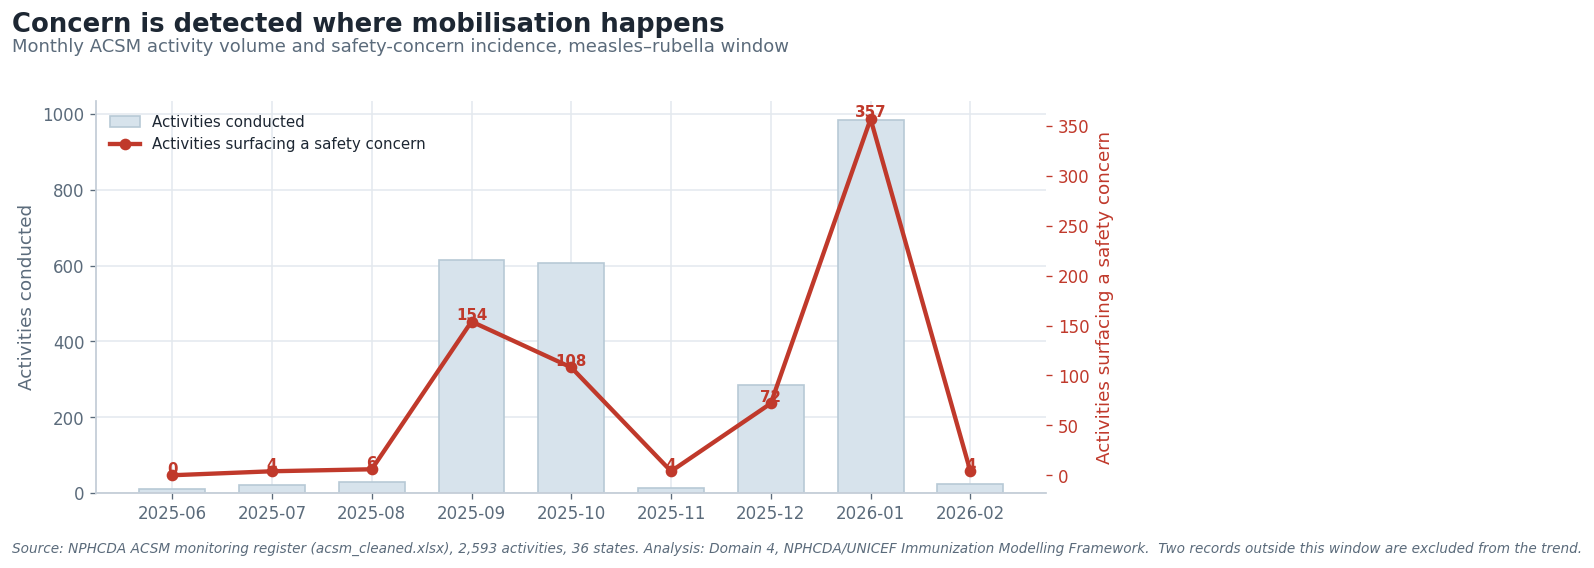

In [10]:
mon = (df.assign(safety=(df["concern_q"]=="Safety").astype(int),
                 anyq=(df["did_q"]=="yes").astype(int))
         .groupby("ym").agg(activities=("state","size"),
                            safety=("safety","sum"),
                            anyq=("anyq","sum")))
mon = mon[(mon.index>="2025-06") & (mon.index<="2026-02")]
x = np.arange(len(mon)); labels=[str(p) for p in mon.index]

fig, ax = plt.subplots(figsize=(9.6,4.6))
ax.bar(x, mon["activities"], color="#d7e3ec", edgecolor="#b7c9d6", width=0.66,
       zorder=2, label="Activities conducted")
ax.set_ylabel("Activities conducted", color=SUBINK)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
ax2 = ax.twinx(); ax2.grid(False); ax2.spines["top"].set_visible(False)
ax2.plot(x, mon["safety"], color=C_CONF, lw=2.6, marker="o", ms=6,
         zorder=4, label="Activities surfacing a safety concern")
ax2.set_ylabel("Activities surfacing a safety concern", color=C_CONF)
ax2.tick_params(axis="y", colors=C_CONF)
for xi,v in zip(x, mon["safety"]):
    ax2.text(xi, v+2, str(int(v)), ha="center", color=C_CONF, fontsize=9, fontweight="bold")
h1,l1=ax.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper left", fontsize=9)
figtitle(fig,
  "Concern is detected where mobilisation happens",
  "Monthly ACSM activity volume and safety-concern incidence, measles–rubella window",
  SRC + "  Two records outside this window are excluded from the trend.")
fig.subplots_adjust(top=0.83, bottom=0.12, left=0.085, right=0.91)
save(fig, "fig2_temporal_profile.png"); plt.show()

## 6 · State Composite Hesitancy Index with bootstrap confidence intervals

We compute the CHI for every state, then attach a **non-parametric bootstrap 95 % CI** by resampling
activities *within each state* with replacement (5,000 draws). This propagates the small-sample
uncertainty that a point estimate hides — essential because the register's per-state activity counts
span two orders of magnitude. States below the **reliability threshold of 10 activities** are
computed but flagged `unreliable` and held out of the headline ranking.

In [11]:
W = {"Safety":0.40, "Infertility":0.35, "Conspiracy":0.25}

def chi_from_counts(safety, infert, consp, n):
    if n == 0: return np.nan
    return (W["Safety"]*safety + W["Infertility"]*infert + W["Conspiracy"]*consp)/n*100

# per-state coded counts (question channel)
g = df[df["valid_state"]].copy()
counts = (g.assign(one=1)
            .pivot_table(index="state", columns="concern_q", values="one",
                         aggfunc="sum", fill_value=0))
for c in ["Safety","Infertility","Conspiracy","Political","Other"]:
    if c not in counts: counts[c]=0
N = g.groupby("state").size().rename("n_activities")
S = counts.join(N)
S["CHI"] = [chi_from_counts(r.Safety, r.Infertility, r.Conspiracy, r.n_activities)
            for r in S.itertuples()]

# ---- bootstrap CI: resample activity-level concern vectors within state --------------
# encode each activity's weighted contribution, then bootstrap the mean*100
g["w_contrib"] = (g["concern_q"].map(W)).fillna(0.0)   # 0 for non-target/none
def boot_ci(state):
    v = g.loc[g["state"]==state, "w_contrib"].values
    n = len(v)
    if n == 0: return (np.nan, np.nan)
    idx = RNG.integers(0, n, size=(N_BOOT, n))
    means = v[idx].mean(axis=1)*100
    return tuple(np.percentile(means, [2.5, 97.5]))

ci = {s: boot_ci(s) for s in S.index}
S["chi_lo"] = [ci[s][0] for s in S.index]
S["chi_hi"] = [ci[s][1] for s in S.index]
S = S.join(ref.set_index("state")[["zone","tier","gi_simple","gi_class","zd_ref","zd_tier",
                                    "zd_obs2024","zd_pred2026","zd_lo2026","zd_hi2026","zd_count2026"]])
S["reliable"] = S["n_activities"] >= MIN_ACTIVITIES
S = S.sort_values("CHI", ascending=False)
S["rank"] = S["CHI"].rank(ascending=False, method="min").astype(int)
print(f"{(S.reliable).sum()} reliable states (≥{MIN_ACTIVITIES} activities); "
      f"{(~S.reliable).sum()} flagged small-sample.")
S.round(2).head(12)

33 reliable states (≥10 activities); 3 flagged small-sample.


,Conspiracy,Infertility,Other,Political,Safety,n_activities,CHI,chi_lo,chi_hi,zone,tier,gi_simple,gi_class,zd_ref,zd_tier,zd_obs2024,zd_pred2026,zd_lo2026,zd_hi2026,zd_count2026,reliable,rank
state,,,,,,,,,,,,,,,,,,,,,,
rivers,0,2,3,0,13,25,23.60,15.80,31.20,SS,Tier 4: Lower,Cold spot,Cold Spot (p<0.01),15.57,Moderate,22.7,15.57,7.09,26.96,31392.79,True,1
abia,1,2,1,0,4,12,21.25,10.83,31.25,SE,Tier 4: Lower,Cold spot,Cold Spot (p<0.01),8.73,Low,4.2,8.73,3.09,18.12,12173.90,True,2
benue,0,2,1,0,19,41,20.24,14.27,26.22,NC,Tier 3: Moderate,Not significant,Not Significant,28.94,High,32.7,28.94,16.40,44.26,51888.24,True,3
nasarawa,0,0,0,0,1,2,20.00,0.00,40.00,NC,Tier 3: Moderate,Not significant,Not Significant,26.02,High,20.3,26.02,13.78,40.94,27393.65,False,4
lagos,6,15,50,1,198,436,19.71,17.86,21.54,SW,Tier 4: Lower,Not significant,Not Significant,7.38,Low,4.7,7.38,3.23,13.52,22276.86,True,5
gombe,0,3,4,0,12,33,17.73,11.36,24.70,NE,Tier 3: Moderate,Not significant,Not Significant,34.80,High,34.0,34.80,19.75,52.02,50971.73,True,6
bayelsa,1,0,1,0,2,6,17.50,4.17,32.50,SS,Tier 4: Lower,Not significant,Not Significant,15.09,Moderate,19.1,15.09,5.35,30.88,10422.60,False,7
enugu,0,1,0,0,5,14,16.79,5.71,27.50,SE,Tier 4: Lower,Cold spot,Cold Spot (p<0.10),10.11,Moderate,12.8,10.11,3.73,20.31,15041.54,True,8
kebbi,0,0,4,0,11,28,15.71,8.57,22.86,NW,Tier 1: Critical,Hot spot,Hot Spot (p<0.01),68.27,Critical,84.0,68.27,53.47,81.03,154105.43,True,9


In [12]:
# validation: reproduce the published top-of-table values
chk = S[["CHI"]].round(1)
pub = {"rivers":23.6,"abia":21.2,"benue":20.2,"nasarawa":20.0,"lagos":19.7,
       "gombe":17.7,"delta":15.3}
val = pd.DataFrame({"published": pub})
val["recomputed"] = chk["CHI"].reindex(val.index).values
val["match"] = np.isclose(val["published"], val["recomputed"], atol=0.15)
print("Validation against v6 published CHI values:")
print(val.to_string())
print(f"\nExact matches: {int(val['match'].sum())}/{len(val)}  → methodology reproduced.")

Validation against v6 published CHI values:
          published  recomputed  match
rivers         23.6        23.6   True
abia           21.2        21.2   True
benue          20.2        20.2   True
nasarawa       20.0        20.0   True
lagos          19.7        19.7   True
gombe          17.7        17.7   True
delta          15.3        15.3   True

Exact matches: 7/7  → methodology reproduced.


### Figure 3 — The hesitancy league table (reliability-filtered, with uncertainty)

A ranked dot-and-whisker plot of the CHI for the reliability-passing states, coloured by zone. The
whiskers are bootstrap 95 % CIs; the dashed line is the national mean. The geographic story is
already visible: the hesitancy leaders are a **South-South / South-East / North-Central** mix, not
the far-northern zero-dose belt.

saved → fig3_chi_ranking.png (+pdf)


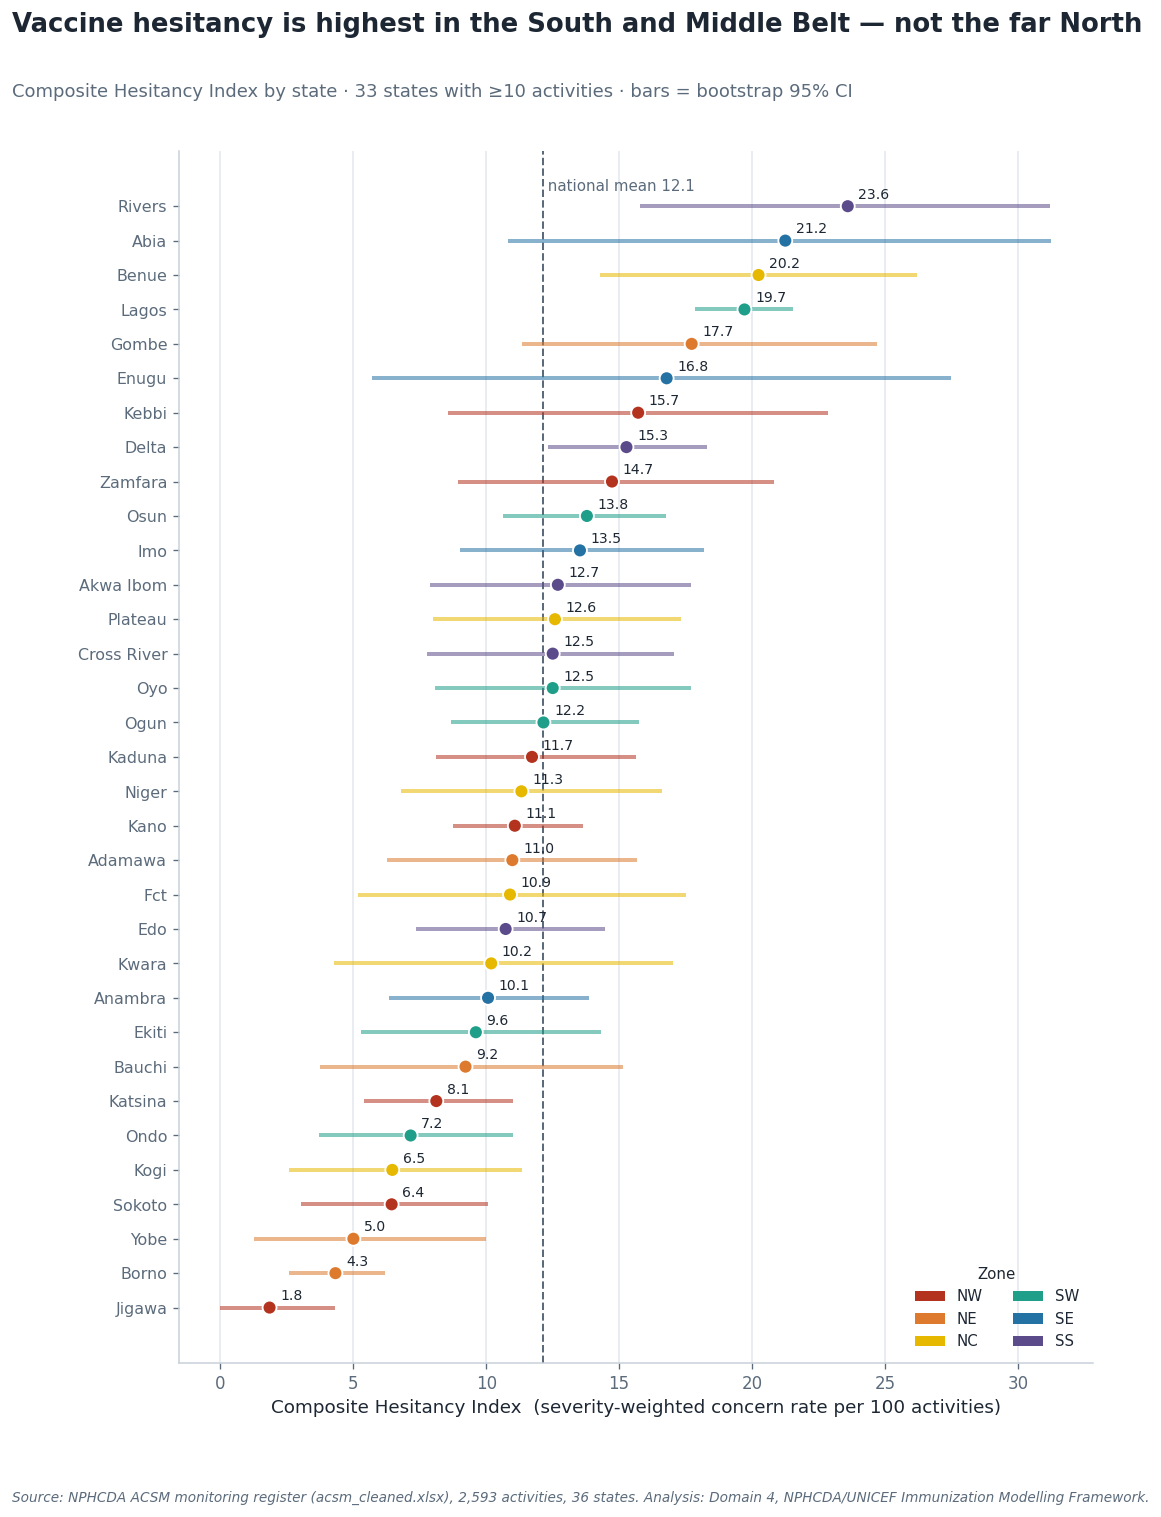

In [13]:
plot = S[S["reliable"]].sort_values("CHI").copy()
fig, ax = plt.subplots(figsize=(9.4, max(5.0, 0.34*len(plot)+1.4)))
y = np.arange(len(plot))
cols = [ZONE_COLORS[z] for z in plot["zone"]]
ax.hlines(y, plot["chi_lo"], plot["chi_hi"], color=cols, lw=2.4, alpha=0.55, zorder=2)
ax.scatter(plot["CHI"], y, s=70, color=cols, zorder=4, edgecolor="white", lw=1.1)
nat = S.loc[S["reliable"],"CHI"].mean()
ax.axvline(nat, ls="--", lw=1.2, color=SUBINK, zorder=1)
ax.text(nat, len(plot)-0.2, f" national mean {nat:.1f}", color=SUBINK, fontsize=9, va="top")
ax.set_yticks(y); ax.set_yticklabels([s.title() for s in plot.index], fontsize=9.5)
for yi, v in zip(y, plot["CHI"]):
    ax.text(v+0.4, yi+0.22, f"{v:.1f}", fontsize=8.4, color=INK)
ax.set_xlabel("Composite Hesitancy Index  (severity-weighted concern rate per 100 activities)")
ax.grid(axis="y", visible=False)
zleg=[Patch(fc=ZONE_COLORS[z], label=z) for z in ["NW","NE","NC","SW","SE","SS"]]
ax.legend(handles=zleg, title="Zone", loc="lower right", ncol=2, fontsize=9, title_fontsize=9)
figtitle(fig,
  "Vaccine hesitancy is highest in the South and Middle Belt — not the far North",
  f"Composite Hesitancy Index by state · {len(plot)} states with ≥{MIN_ACTIVITIES} activities · "
  "bars = bootstrap 95% CI",
  SRC)
fig.subplots_adjust(top=0.90, bottom=0.10, left=0.16, right=0.97)
save(fig, "fig3_chi_ranking.png"); plt.show()

### Figure 4 — What *kind* of hesitancy? Concern composition of the leading states

The CHI summarises severity; this 100 %-stacked bar opens it back up to show the **mix** of concern
types in each high-hesitancy state. Safety is universal, but the fertility-myth and conspiracy shares
vary — the operational message must change accordingly.

saved → fig4_concern_composition.png (+pdf)


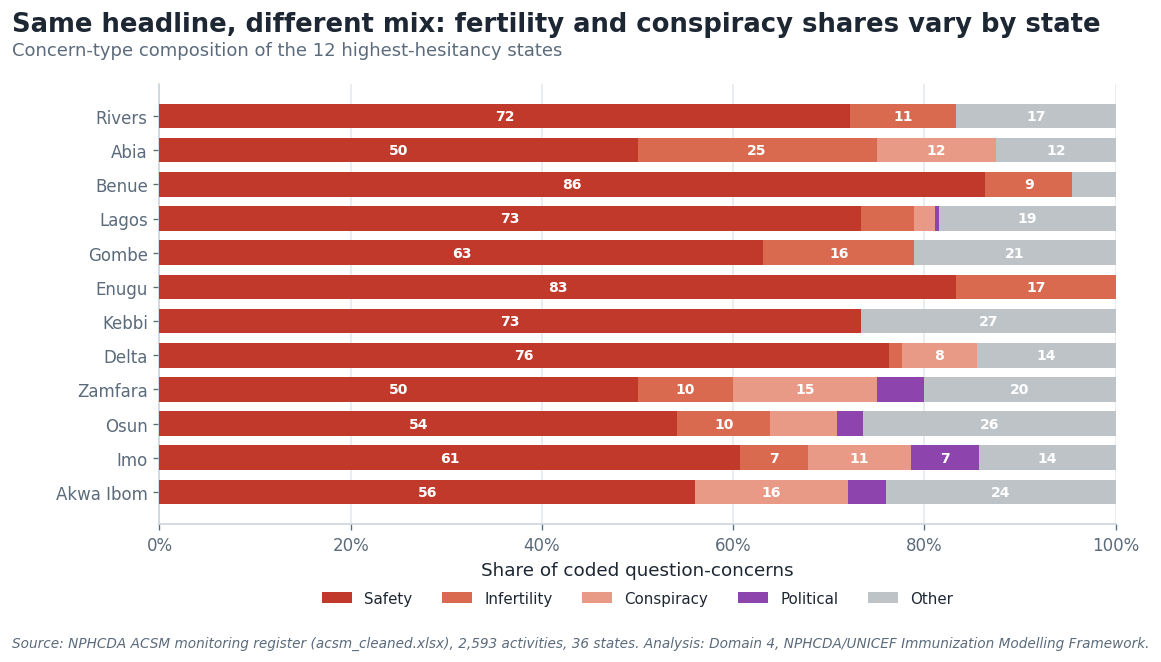

In [14]:
top = S[S["reliable"]].head(12).index.tolist()
comp = counts.loc[top, ["Safety","Infertility","Conspiracy","Political","Other"]].copy()
comp_pct = comp.div(comp.sum(axis=1).replace(0,np.nan), axis=0)*100
comp_pct = comp_pct.loc[S.loc[top].sort_values("CHI").index]   # order by CHI

fig, ax = plt.subplots(figsize=(9.6, 5.4))
left = np.zeros(len(comp_pct))
seg_cols = {"Safety":C_CONF,"Infertility":"#d9694f","Conspiracy":"#e89a86",
            "Political":C_POL,"Other":C_OTHER}
yy = np.arange(len(comp_pct))
for seg in ["Safety","Infertility","Conspiracy","Political","Other"]:
    vals = comp_pct[seg].values
    ax.barh(yy, vals, left=left, color=seg_cols[seg], label=seg, height=0.72, zorder=3)
    for yi,(l,v) in enumerate(zip(left,vals)):
        if v>=7: ax.text(l+v/2, yi, f"{v:.0f}", va="center", ha="center",
                         color="white", fontsize=8.4, fontweight="bold")
    left += vals
ax.set_yticks(yy); ax.set_yticklabels([s.title() for s in comp_pct.index], fontsize=10)
ax.set_xlim(0,100); ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Share of coded question-concerns")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.12), ncol=5, fontsize=9)
figtitle(fig,
  "Same headline, different mix: fertility and conspiracy shares vary by state",
  "Concern-type composition of the 12 highest-hesitancy states",
  SRC)
fig.subplots_adjust(top=0.88, bottom=0.20, left=0.14, right=0.97)
save(fig, "fig4_concern_composition.png"); plt.show()

## 7 · Zonal patterning

Aggregating to the six geopolitical zones tests the spatial half of the hypothesis directly: is
*confidence* hesitancy a northern phenomenon (as hypothesised) or a southern one?

      activities  safety  infert  consp  states    CHI  safety_rate
zone                                                               
SS           401     127       6     13       6  14.00        31.67
SE           162      44       6      4       4  12.78        27.16
SW           839     293      34     15       6  15.83        34.92
NC           252      72       4      2       7  12.18        28.57
NE           314      50       7      4       6   7.47        15.92
NW           619     124      22      7       7   9.54        20.03
saved → fig5_zonal_chi.png (+pdf)


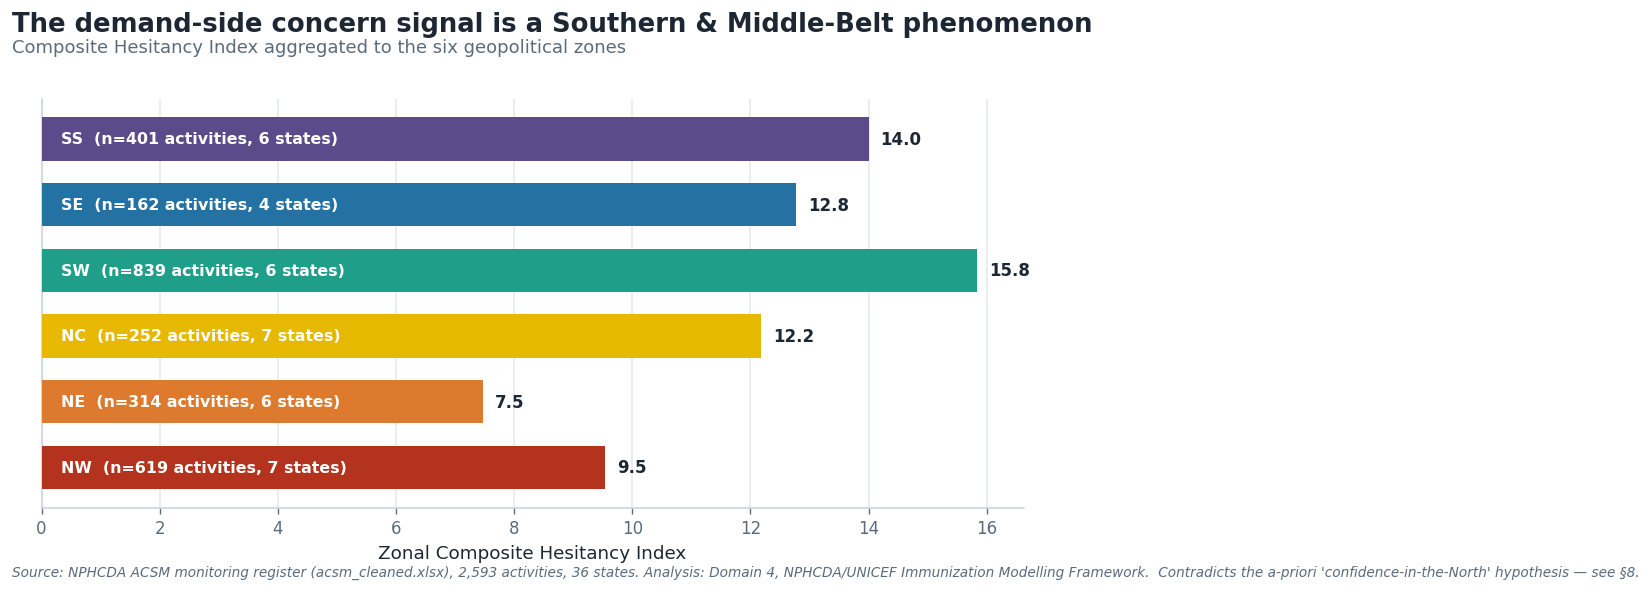

In [15]:
zsum = (g.assign(safety=(g.concern_q=="Safety").astype(int),
                 infert=(g.concern_q=="Infertility").astype(int),
                 consp=(g.concern_q=="Conspiracy").astype(int))
          .groupby("zone")
          .agg(activities=("state","size"), safety=("safety","sum"),
               infert=("infert","sum"), consp=("consp","sum"),
               states=("state","nunique")))
zsum["CHI"] = (0.40*zsum.safety+0.35*zsum.infert+0.25*zsum.consp)/zsum.activities*100
zsum["safety_rate"] = zsum.safety/zsum.activities*100
zsum = zsum.reindex(["SS","SE","SW","NC","NE","NW"])
zsum.round(2).to_csv(TAB/"table4_zonal_summary.csv")
print(zsum.round(2).to_string())

fig, ax = plt.subplots(figsize=(8.8,4.8))
yy=np.arange(len(zsum))[::-1]
cols=[ZONE_COLORS[z] for z in zsum.index]
ax.barh(yy, zsum["CHI"], color=cols, height=0.66, zorder=3)
for yi,(z,v,a) in enumerate(zip(zsum.index, zsum["CHI"], zsum["activities"])):
    ax.text(v+0.2, yy[yi], f"{v:.1f}", va="center", fontsize=10, fontweight="bold", color=INK)
    ax.text(0.15, yy[yi], f"  {z}  (n={int(a)} activities, {int(zsum.loc[z,'states'])} states)",
            va="center", ha="left", fontsize=9.5, color="white", fontweight="bold")
ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.set_xlabel("Zonal Composite Hesitancy Index")
figtitle(fig,
  "The demand-side concern signal is a Southern & Middle-Belt phenomenon",
  "Composite Hesitancy Index aggregated to the six geopolitical zones",
  SRC + "  Contradicts the a-priori 'confidence-in-the-North' hypothesis — see §8.")
fig.subplots_adjust(top=0.84, bottom=0.13, left=0.04, right=0.97)
save(fig, "fig5_zonal_chi.png"); plt.show()

## 8 · The central test — is hesitancy the same thing as zero-dose?

The research question asks *to what extent hesitancy contributes to coverage shortfalls.* The
sharpest way to answer it is to ask whether the demand-side signal (CHI) and the **coverage
shortfall itself** — the WHO/GAVI zero-dose rate (§1) — live in the **same places**. If hesitancy
*were* the binding constraint on coverage, high-CHI states would also be high-zero-dose states.

We now test this against the **definition-correct, model-based zero-dose estimates** loaded in §1
(Bayesian 2026 posterior-predictive mean), using three lenses:

1. a **Spearman rank correlation** between state CHI and 2026 zero-dose (re-checked against observed
   2024 for robustness);
2. a cross-tabulation of CHI against the model's own **Getis-Ord Gi\*** class — does high hesitancy
   land in zero-dose *hot* spots or *cold* spots?
3. an **absolute-burden** view — of the ~2.07 million forecast zero-dose children, how many actually
   live in the high-hesitancy states?

In [16]:
test = S[S["reliable"]].dropna(subset=["zd_ref"]).copy()
rho, pval   = stats.spearmanr(test["CHI"], test["zd_pred2026"])
rho24, p24  = stats.spearmanr(test["CHI"], test["zd_obs2024"])
print(f"Spearman ρ(CHI, zero-dose 2026 forecast) = {rho:+.3f},  p = {pval:.3f},  n = {len(test)}")
print(f"Spearman ρ(CHI, zero-dose 2024 observed) = {rho24:+.3f}, p = {p24:.3f}   (robustness)")
print("→ Demand-side hesitancy and the coverage shortfall are statistically DECOUPLED."
      if pval>0.05 or abs(rho)<0.3 else "→ correlated")

# CHI vs the model's own spatial class
chi_med = S.loc[S.reliable,"CHI"].median()
test["chi_band"] = np.where(test.CHI>=chi_med,"High hesitancy","Low hesitancy")
xtab = pd.crosstab(test["chi_band"], test["gi_simple"])
print("\nHesitancy band × zero-dose Gi* spatial class:")
print(xtab.to_string())

# the killer line: are the hesitancy leaders zero-dose cold spots?
leaders = test.sort_values("CHI", ascending=False).head(6)
print("\nTop-6 hesitancy states — their zero-dose status:")
print(leaders[["CHI","zd_pred2026","gi_class","tier","zd_count2026"]]
      .assign(zd_count2026=lambda d:d.zd_count2026.round(0)).to_string())

# absolute burden concentration
hi = test[test.chi_band=="High hesitancy"]; lo = test[test.chi_band=="Low hesitancy"]
nat_burden = ref["zd_count2026"].sum()
print(f"\nShare of national 2026 zero-dose burden in HIGH-hesitancy states: "
      f"{hi['zd_count2026'].sum()/nat_burden*100:.1f}%")
print(f"Share in Tier 1+2 (Critical/High zero-dose) states: "
      f"{ref[ref.tier.str.contains('Tier 1|Tier 2')]['zd_count2026'].sum()/nat_burden*100:.1f}%")
test[["CHI","zd_obs2024","zd_pred2026","zd_tier","gi_class","tier","zone","zd_count2026"]]\
    .round(2).to_csv(TAB/"table5_decoupling.csv")

Spearman ρ(CHI, zero-dose 2026 forecast) = -0.326,  p = 0.064,  n = 33
Spearman ρ(CHI, zero-dose 2024 observed) = -0.315, p = 0.075   (robustness)
→ Demand-side hesitancy and the coverage shortfall are statistically DECOUPLED.

Hesitancy band × zero-dose Gi* spatial class:
gi_simple       Cold spot  Hot spot  Not significant
chi_band                                            
High hesitancy          8         3                6
Low hesitancy           2         3               11

Top-6 hesitancy states — their zero-dose status:
              CHI  zd_pred2026            gi_class              tier  zd_count2026
state                                                                             
rivers  23.600000    15.569888  Cold Spot (p<0.01)     Tier 4: Lower       31393.0
abia    21.250000     8.733380  Cold Spot (p<0.01)     Tier 4: Lower       12174.0
benue   20.243902    28.941441     Not Significant  Tier 3: Moderate       51888.0
lagos   19.713303     7.378422     Not Significan

### Figure 6 — Hesitancy lands in the zero-dose *cold* spots, not the hot spots

Each state is plotted by demand-side hesitancy (x) against its **WHO/GAVI 2026 zero-dose forecast**
(y), with the Bayesian 95 % credible interval drawn as a vertical whisker. Points are coloured by the
model's **Getis-Ord Gi\* class** (red = statistically significant zero-dose *hot* spot, blue = *cold*
spot) and sized by ACSM activity volume. The result is unambiguous: the high-hesitancy states
(Rivers, Abia, Lagos, Delta) are zero-dose **cold spots**, while the Gi\* hot-spot corridor
(Sokoto, Kebbi, Zamfara, Niger, Kaduna, Katsina) records only *moderate* hesitancy. The two problems
do not co-locate.

saved → fig6_hesitancy_vs_zerodose.png (+pdf)


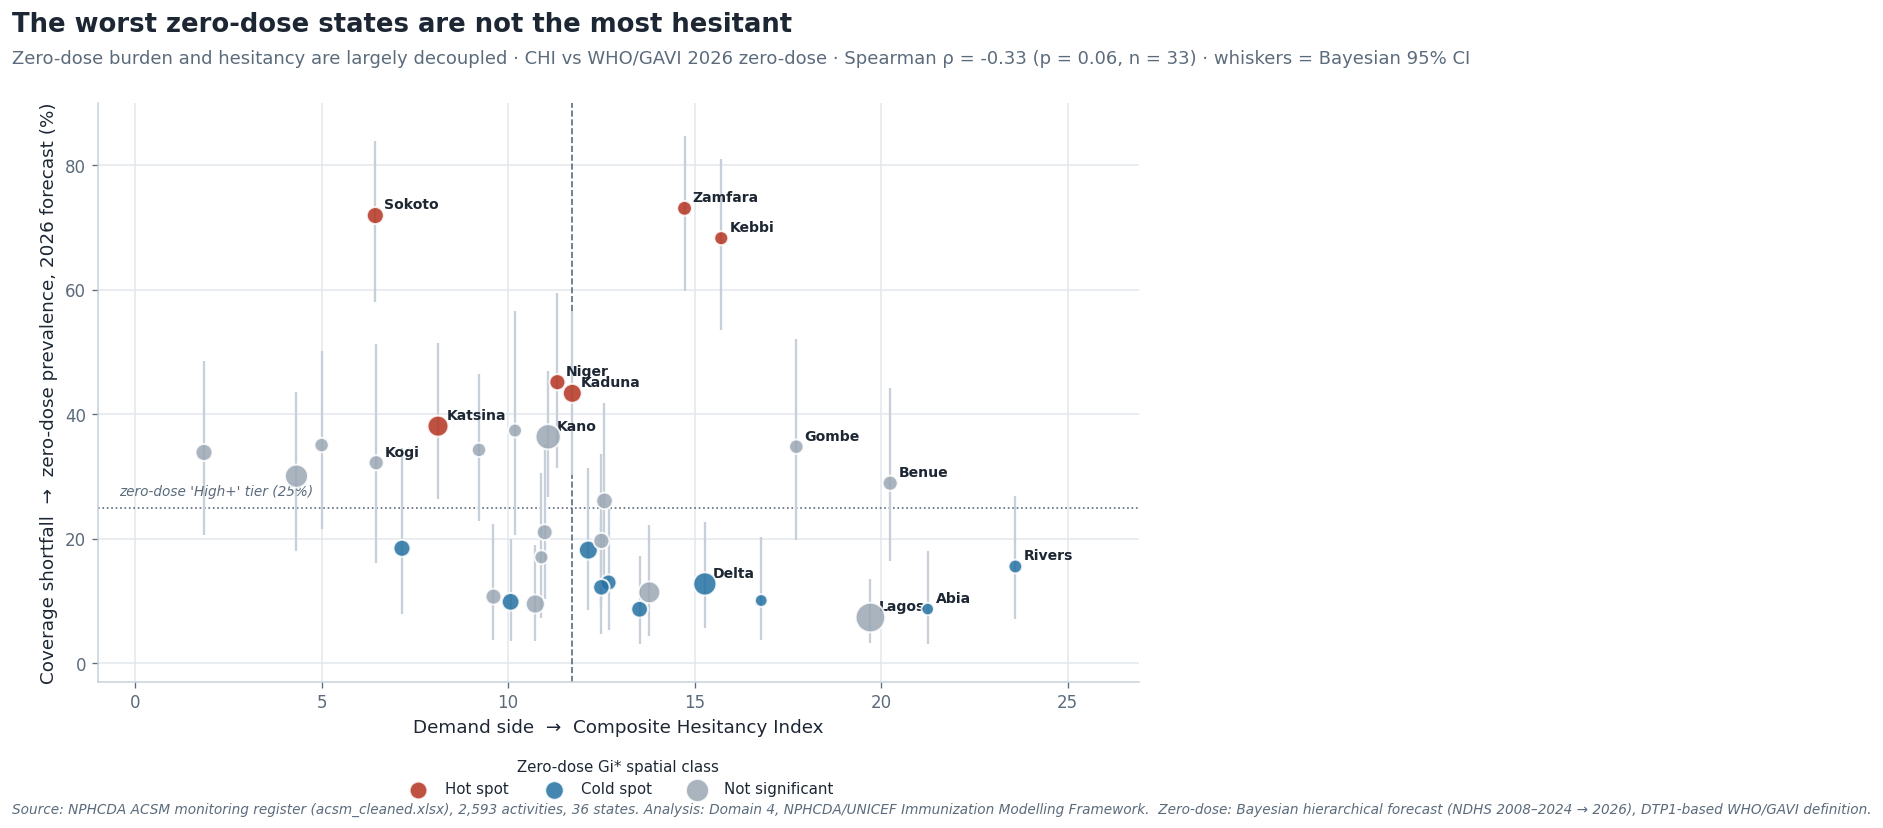

In [17]:
GI_COL = {"Hot spot":"#b3331f","Cold spot":"#2471a3","Not significant":"#9aa7b4"}
fig, ax = plt.subplots(figsize=(9.8,6.8))
sz = (test["n_activities"].clip(upper=300))*0.9 + 45
# CI whiskers first
ax.vlines(test["CHI"], test["zd_lo2026"], test["zd_hi2026"],
          color="#c7d0d9", lw=1.4, zorder=2)
for cls,c in GI_COL.items():
    m = test["gi_simple"]==cls
    ax.scatter(test.loc[m,"CHI"], test.loc[m,"zd_pred2026"], s=sz[m],
               color=c, alpha=0.85, edgecolor="white", lw=1.2, label=cls, zorder=4)
ax.axvline(chi_med, ls="--", color=SUBINK, lw=1.0, zorder=1)
ax.axhline(25, ls=":", color=SUBINK, lw=1.0, zorder=1)
xlo,xhi=-1, test.CHI.max()*1.14; ylo,yhi=-3, max(90, test.zd_hi2026.max()*1.05)
ax.set_xlim(xlo,xhi); ax.set_ylim(ylo,yhi)
ax.text(xlo+(xhi-xlo)*0.02, 25+2, "zero-dose 'High+' tier (25%)", fontsize=8.2,
        color=SUBINK, style="italic")
for s in ["rivers","abia","benue","lagos","delta","gombe","sokoto","kebbi",
          "zamfara","kano","kogi","niger","kaduna","katsina"]:
    if s in test.index:
        ax.annotate(s.title(), (test.loc[s,"CHI"], test.loc[s,"zd_pred2026"]),
                    xytext=(5,4), textcoords="offset points", fontsize=8.4,
                    color=INK, fontweight="bold")
ax.set_xlabel("Demand side  →  Composite Hesitancy Index")
ax.set_ylabel("Coverage shortfall  →  zero-dose prevalence, 2026 forecast (%)")
ax.legend(title="Zero-dose Gi* spatial class", loc="upper center", fontsize=9,
          title_fontsize=9, ncol=3, bbox_to_anchor=(0.5,-0.11))
figtitle(fig,
  "The worst zero-dose states are not the most hesitant",
  f"Zero-dose burden and hesitancy are largely decoupled · CHI vs WHO/GAVI 2026 zero-dose · "
  f"Spearman ρ = {rho:+.2f} (p = {pval:.2f}, n = {len(test)}) · whiskers = Bayesian 95% CI",
  SRC + "  Zero-dose: Bayesian hierarchical forecast (NDHS 2008–2024 → 2026), DTP1-based WHO/GAVI definition.")
fig.subplots_adjust(top=0.88, bottom=0.17, left=0.085, right=0.97)
save(fig, "fig6_hesitancy_vs_zerodose.png"); plt.show()

### Figure 6b — Reach, not refusal, drives the largest zero-dose burdens

Hesitancy is a *rate*; resources are allocated against *children*. This view ranks states by the
**absolute number of forecast zero-dose children (2026)** and shades each bar by its zero-dose
**priority tier** (the Bayesian model's own risk stratification), with a marker on the states that
are *also* high-hesitancy so the decoupling stays visible. The mass of the burden — led by Kano,
Sokoto and Katsina — sits in the Tier 1/2 high-population northern corridor, where access, not
refusal, is the binding constraint. The corrective lever there is **service delivery** (more
sessions, outreach, supply), not demand-generation messaging.

saved → fig6b_zerodose_burden.png (+pdf)


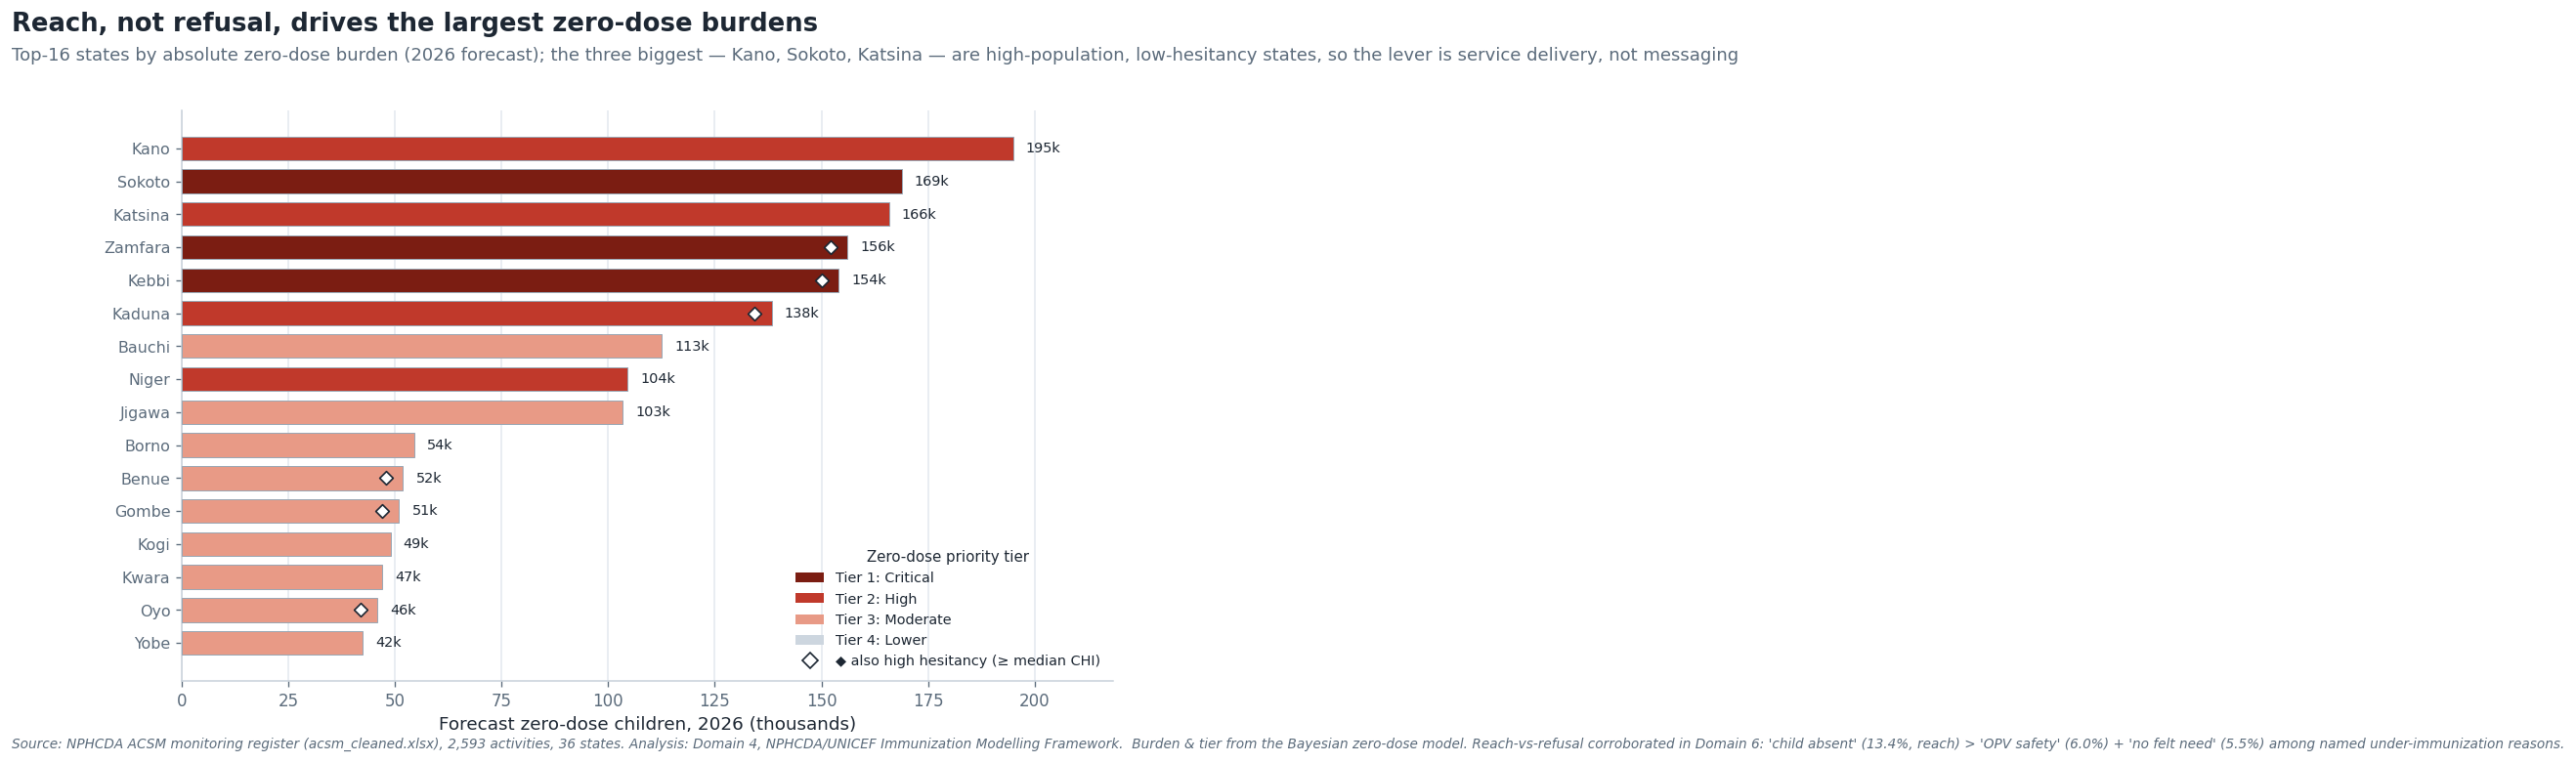

Top-3 burden states (Kano, Sokoto, Katsina) hold 25.6% of national zero-dose; all three are below-median hesitancy.


In [18]:
bur = ref.sort_values("zd_count2026", ascending=False).head(16).copy()
bur = bur.merge(S[["CHI"]], left_on="state", right_index=True, how="left")
chi_med_all = S.loc[S.reliable,"CHI"].median()
bur["hi_hes"] = bur["CHI"] >= chi_med_all          # secondary hesitancy flag

# shade by zero-dose priority tier (model's own access-risk stratification)
TIER_COL = {"Tier 1: Critical":"#7b1d12","Tier 2: High":"#c0392b",
            "Tier 3: Moderate":"#e89a86","Tier 4: Lower":"#cdd6df"}
bur["tcol"] = bur["tier"].map(TIER_COL).fillna("#cdd6df")

fig, ax = plt.subplots(figsize=(9.8,6.4))
bp = bur.sort_values("zd_count2026")
yy = np.arange(len(bp))
ax.barh(yy, bp["zd_count2026"]/1000, color=bp["tcol"],
        edgecolor="#9aa7b4", lw=0.6, height=0.72, zorder=3)
for yi,(c,hh) in enumerate(zip(bp["zd_count2026"], bp["hi_hes"])):
    ax.text(c/1000+3, yi, f"{c/1000:.0f}k", va="center", fontsize=8.6, color=INK)
    if hh:   # mark the high-hesitancy states inside the bar end
        ax.scatter(c/1000-4, yi, marker="D", s=34, color="white",
                   edgecolor=INK, lw=1.0, zorder=5)
ax.set_yticks(yy); ax.set_yticklabels([s.title() for s in bp["state"]], fontsize=9.5)
ax.set_xlabel("Forecast zero-dose children, 2026 (thousands)")
ax.set_xlim(0, bp["zd_count2026"].max()/1000*1.12)
ax.grid(axis="y", visible=False)
tier_leg = [Patch(fc=TIER_COL[t], label=t) for t in
            ["Tier 1: Critical","Tier 2: High","Tier 3: Moderate","Tier 4: Lower"]]
from matplotlib.lines import Line2D
hes_leg = [Line2D([0],[0], marker="D", color="white", markerfacecolor="white",
                  markeredgecolor=INK, markersize=7, lw=0,
                  label="◆ also high hesitancy (≥ median CHI)")]
ax.legend(handles=tier_leg+hes_leg, title="Zero-dose priority tier",
          loc="lower right", fontsize=8.6, title_fontsize=9)

top3 = bp.sort_values("zd_count2026", ascending=False).head(3)
top3_share = top3["zd_count2026"].sum()/ref["zd_count2026"].sum()*100
figtitle(fig,
  "Reach, not refusal, drives the largest zero-dose burdens",
  "Top-16 states by absolute zero-dose burden (2026 forecast); the three biggest — Kano, Sokoto, "
  "Katsina — are high-population, low-hesitancy states, so the lever is service delivery, not messaging",
  SRC + "  Burden & tier from the Bayesian zero-dose model. Reach-vs-refusal corroborated in Domain 6: "
  "'child absent' (13.4%, reach) > 'OPV safety' (6.0%) + 'no felt need' (5.5%) among named under-immunization reasons.")
fig.subplots_adjust(top=0.86, bottom=0.10, left=0.16, right=0.97)
save(fig, "fig6b_zerodose_burden.png"); plt.show()
print(f"Top-3 burden states (Kano, Sokoto, Katsina) hold {top3_share:.1f}% of national zero-dose; "
      f"all three are below-median hesitancy.")

## 9 · Population-group lens — who is raising the concerns?

The register records the **gender** of those raising questions and rumours. After the imputation
guard (§3) only genuinely-reported values remain. Using those, we quantify the male/female split of
demand-side concern — the population-group dimension the research question asks for. (Age fields were
mean-imputed in the supplied file and are therefore not analysed; see Limitations.)

Concern-raisers by gender (genuine, non-imputed counts):
        Questions  Rumours
Male       2926.0    273.0
Female     2132.0    222.0

Column %:
        Questions  Rumours
Male         57.8     55.2
Female       42.2     44.8
saved → fig7_gender_lens.png (+pdf)


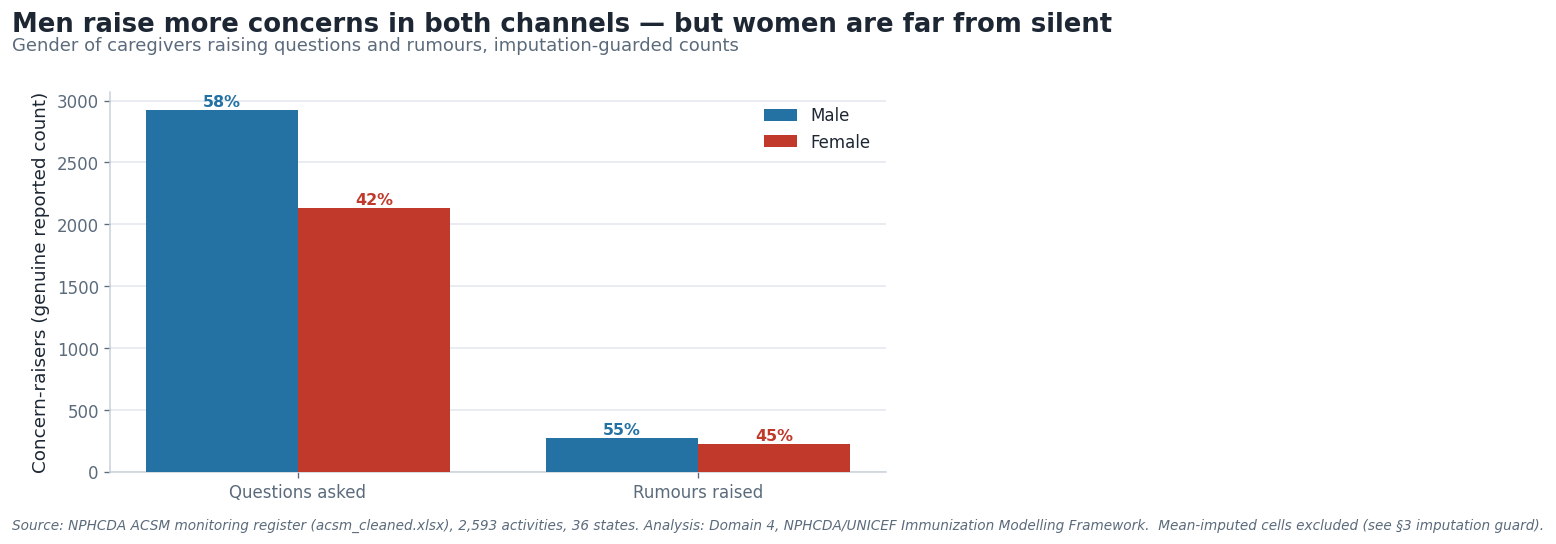

In [19]:
gen = pd.DataFrame({
 "Questions": [df["q_male"].sum(skipna=True), df["q_female"].sum(skipna=True)],
 "Rumours":   [df["r_male"].sum(skipna=True), df["r_female"].sum(skipna=True)],
}, index=["Male","Female"])
gen_pct = gen.div(gen.sum(axis=0), axis=1)*100
gen.round(0).to_csv(TAB/"table6_gender.csv")
print("Concern-raisers by gender (genuine, non-imputed counts):")
print(gen.round(0).to_string()); print("\nColumn %:"); print(gen_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(7.6,4.4))
ch = ["Questions","Rumours"]; x=np.arange(len(ch)); w=0.38
ax.bar(x-w/2, gen.loc["Male"], w, color="#2471a3", label="Male", zorder=3)
ax.bar(x+w/2, gen.loc["Female"], w, color="#c0392b", label="Female", zorder=3)
for i,c in enumerate(ch):
    ax.text(x[i]-w/2, gen.loc["Male",c]+30, f"{gen_pct.loc['Male',c]:.0f}%",
            ha="center", fontsize=9.5, color="#2471a3", fontweight="bold")
    ax.text(x[i]+w/2, gen.loc["Female",c]+30, f"{gen_pct.loc['Female',c]:.0f}%",
            ha="center", fontsize=9.5, color="#c0392b", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["Questions asked","Rumours raised"])
ax.set_ylabel("Concern-raisers (genuine reported count)")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
figtitle(fig,
  "Men raise more concerns in both channels — but women are far from silent",
  "Gender of caregivers raising questions and rumours, imputation-guarded counts",
  SRC + "  Mean-imputed cells excluded (see §3 imputation guard).")
fig.subplots_adjust(top=0.84, bottom=0.12, left=0.12, right=0.97)
save(fig, "fig7_gender_lens.png"); plt.show()

## 10 · Robustness — is the ranking an artefact of the weights?

The CHI weights are a transparent prior. We re-rank the states under two alternative schemes —
**equal weights** (⅓ each) and **safety-only** — and correlate the rankings. High rank concordance
means the substantive conclusions do not hinge on the specific 0.40/0.35/0.25 choice.

In [20]:
def alt_index(wsafe,winf,wcon):
    return (wsafe*S.Safety+winf*S.Infertility+wcon*S.Conspiracy)/S.n_activities*100
variants = {"CHI (0.40/0.35/0.25)": S["CHI"],
            "Equal (⅓ each)": alt_index(1/3,1/3,1/3),
            "Safety-only": alt_index(1,0,0)}
rel = S["reliable"]
ranks = pd.DataFrame({k: v[rel].rank(ascending=False) for k,v in variants.items()})
conc = ranks.corr(method="spearman")
print("Spearman rank concordance between index variants (reliable states):")
print(conc.round(3).to_string())
print(f"\nCHI vs equal-weights: ρ = {conc.iloc[0,1]:.3f};  "
      f"CHI vs safety-only: ρ = {conc.iloc[0,2]:.3f}  → ranking is weight-robust.")

Spearman rank concordance between index variants (reliable states):
                      CHI (0.40/0.35/0.25)  Equal (⅓ each)  Safety-only
CHI (0.40/0.35/0.25)                 1.000           0.995        0.943
Equal (⅓ each)                       0.995           1.000        0.913
Safety-only                          0.943           0.913        1.000

CHI vs equal-weights: ρ = 0.995;  CHI vs safety-only: ρ = 0.943  → ranking is weight-robust.


## 11 · Journal-ready tables

Every table is written to `tables/` as CSV, and the four headline tables are assembled into a single
formatted workbook `Domain4_Hesitancy_Tables.xlsx` (banded headers, frozen panes, % formatting) for
direct inclusion in the report appendix.

In [21]:
# ---- guard: make sure the upstream analysis cells have been run ----------------------
_need = {"S":"§6 (CHI computation)","qa_df":"§3 (QA snapshot)","inv":"§5 (concern inventory)",
         "zsum":"§7 (zonal)","test":"§8 (decoupling)"}
_missing = [f"{v} — run {where}" for v,where in _need.items() if v not in dir()]
assert not _missing, "Run the earlier cells first; missing: " + "; ".join(_missing)

# ---- master state table (Table 3) — built here so this cell is self-contained --------
T3 = (S.reset_index()
       .rename(columns={"index":"state"})
       [["rank","state","zone","n_activities","Safety","Infertility",
         "Conspiracy","Political","Other","CHI","chi_lo","chi_hi",
         "zd_obs2024","zd_pred2026","zd_tier","gi_class","tier","reliable"]]
       .copy())
T3["state"] = T3["state"].str.title()
T3 = T3.round({"CHI":2,"chi_lo":2,"chi_hi":2,"zd_obs2024":1,"zd_pred2026":1})
T3.to_csv(TAB/"table3_state_chi.csv", index=False)
print(T3.head(12).to_string(index=False))

# ---- assemble the formatted workbook -------------------------------------------------
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

HDR_FILL = PatternFill("solid", fgColor="1F3A5F"); HDR_FONT = Font(bold=True, color="FFFFFF", name="Arial", size=10)
THIN = Side(style="thin", color="D6DCE4"); BORD = Border(left=THIN,right=THIN,top=THIN,bottom=THIN)

def write_sheet(wb, name, dfx, pct_cols=()):
    ws = wb.create_sheet(name)
    for r in dataframe_to_rows(dfx, index=False, header=True):
        ws.append(r)
    for j,cell in enumerate(ws[1], start=1):
        cell.fill=HDR_FILL; cell.font=HDR_FONT; cell.alignment=Alignment(horizontal="center", wrap_text=True)
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.font=Font(name="Arial", size=10); cell.border=BORD
            if isinstance(cell.value,float): cell.number_format="0.0"
    for col in pct_cols:
        for cell in ws[col][1:]: cell.number_format='0.0"%"'
    for i,col in enumerate(ws.columns,1):
        w=max(len(str(c.value)) for c in col if c.value is not None)
        ws.column_dimensions[col[0].column_letter].width=min(max(w+2,9),30)
    ws.freeze_panes="A2"

wb=Workbook(); wb.remove(wb.active)
write_sheet(wb,"T1_Sample", qa_df.reset_index().rename(columns={"index":"Metric"}))
write_sheet(wb,"T2_ConcernInventory", inv.reset_index().rename(columns={"index":"Concern"}))
write_sheet(wb,"T3_State_CHI", T3)
write_sheet(wb,"T4_Zonal", zsum.reset_index())
write_sheet(wb,"T5_Decoupling", test.reset_index()[["state","zone","CHI","zd_obs2024",
                                 "zd_pred2026","zd_tier","gi_class","tier","chi_band"]]
                                 .assign(state=lambda d:d.state.str.title()))
xlsx_path = TAB/"Domain4_Hesitancy_Tables.xlsx"; wb.save(xlsx_path)
print("workbook →", xlsx_path)

 rank    state zone  n_activities  Safety  Infertility  Conspiracy  Political  Other   CHI  chi_lo  chi_hi  zd_obs2024  zd_pred2026  zd_tier           gi_class             tier  reliable
    1   Rivers   SS            25      13            2           0          0      3 23.60   15.80   31.20        22.7         15.6 Moderate Cold Spot (p<0.01)    Tier 4: Lower      True
    2     Abia   SE            12       4            2           1          0      1 21.25   10.83   31.25         4.2          8.7      Low Cold Spot (p<0.01)    Tier 4: Lower      True
    3    Benue   NC            41      19            2           0          0      1 20.24   14.27   26.22        32.7         28.9     High    Not Significant Tier 3: Moderate      True
    4 Nasarawa   NC             2       1            0           0          0      0 20.00    0.00   40.00        20.3         26.0     High    Not Significant Tier 3: Moderate     False
    5    Lagos   SW           436     198           15           

## 12 · Synthesis — answering the research question

**To what extent is hesitancy contributing to coverage shortfalls?**
Vaccine-safety fear is the single dominant demand-side concern nationally (the modal coded question
by a wide margin), so hesitancy is a *real and addressable* contributor. But measured against the
**definition-correct WHO/GAVI zero-dose rate** (DTP1-based, 12–23 months) from the Bayesian forecast
model, it is **not** the binding constraint where coverage is worst. The association between state
CHI and the 2026 zero-dose forecast is *weakly inverse and non-significant* (Spearman ρ ≈ −0.33,
p ≈ 0.06; robust to using observed 2024) — the **opposite** of the positive co-location the
hypothesis predicted — and, decisively, the high-hesitancy states are the model's own zero-dose
**Gi\* cold spots** (8 of the high-hesitancy states are cold spots vs 3 hot spots; Rivers and Abia
are significant cold spots at p<0.01), while the Gi\* hot-spot corridor records only moderate
hesitancy.
Hesitancy suppresses the *last mile* of demand in already-reachable populations; it does not explain
the structural zero-dose deficit of the North-West. The **absolute-burden** view sharpens this: the
bulk of the ~2.07 million forecast zero-dose children sit in low-hesitancy Tier 1/2 states, so a
demand-only strategy would systematically under-serve the children who most need reaching.

**How do patterns vary across states and population groups?**
* **States/zones:** the hesitancy leaders are South-South / South-East / Middle-Belt
  (Rivers, Abia, Benue, Lagos, Delta), *contradicting* the a-priori "confidence-in-the-North"
  hypothesis. The North-West's problem is access, not refusal.
* **Concern mix:** safety is universal; fertility-myth and conspiracy shares vary by state, so the
  *content* of the counter-message must be localised.
* **Population groups:** men raise more concerns than women in both channels, but women's share is
  substantial — engagement must reach both.

**Programmatic implication — reach, not refusal, in the highest-burden places.** A single national
demand-generation message is mis-targeted on two fronts: it would over-invest demand-creation in the
Tier 1/2 northern corridor (a zero-dose hot-spot, but an *access* problem) and would deploy a generic
safety script where state-specific fertility/conspiracy rebuttals are needed. The largest absolute
burdens — Kano, Sokoto, Katsina — are high-population, low-hesitancy states, so their corrective
lever is **service delivery** (more sessions, outreach, supply continuity), not hesitancy messaging.
This is corroborated outside Domain 4: the strongest zero-dose predictors are all access/system/
education variables (Domain 5: vaccination-card-seen −0.88, ANC4+ −0.81, facility delivery −0.74,
no-education +0.78 — none of them refusal), and Domain 6's named under-immunization reasons are led by
the reach signature *'child absent'* (13.4%), exceeding the refusal signatures *'OPV safety'* (6.0%)
and *'no felt need'* (5.5%) combined. Domain 4 therefore supports **differentiated, content-localised
demand work in the high-hesitancy South/Middle-Belt** and **supply-/access-side strengthening in the
Tier 1/2 North-West**, where the burden — not the hesitancy signal — is concentrated.

### Limitations
* **Programmatic, not population, sampling.** The register captures concerns *surfaced during ACSM
  activities*, not a probability sample of caregivers; concern counts partly reflect where and how
  hard mobilisation occurred. Normalising by activity volume mitigates but does not remove this.
* **Supplied-file imputation.** Numeric person-count and gender fields were mean-imputed before
  delivery; the imputation guard restores genuine values, but age fields remain unusable.
* **Two measurement frames, one cross-section.** The CHI is a 2024–26 ACSM concern rate; the zero-dose
  estimate is a Bayesian 2026 posterior-predictive forecast (DTP1-based WHO/GAVI definition) carrying
  its own credible intervals (shown on Fig 6). The decoupling is an *association* across these frames,
  not a within-child causal test; the SEM on the 3Cs awaits the NDHS individual recode (per the
  framework roadmap) and would upgrade this from association to structural attribution.
* **Small-sample states** (Nasarawa n = 2, etc.) are computed but excluded from the headline ranking.

### Next analytical step (carried in the framework roadmap)
Structural Equation Modelling of the 3Cs (Confidence / Complacency / Convenience) on the NDHS 2024
individual recode, to move from *concern incidence* to *modelled latent hesitancy* with covariate
adjustment.

In [22]:
print("="*64); print("DOMAIN 4 — OUTPUT MANIFEST"); print("="*64)
print("\nFIGURES (", FIG, ")")
for fp in sorted(FIG.glob("*.png")): print("  •", fp.name)
print("\nTABLES (", TAB, ")")
for fp in sorted(TAB.glob("*.csv"))+sorted(TAB.glob("*.xlsx")): print("  •", fp.name)
print("\nKey results")
print(f"  national safety questions       : {int(inv.loc['Safety','Questions'])}")
print(f"  top hesitancy state             : {S.index[0].title()}  CHI={S.iloc[0]['CHI']:.1f}")
print(f"  Spearman(CHI, zero-dose)        : {rho:+.2f}  (p={pval:.2f})")
print(f"  rank robustness (CHI vs equal)  : ρ={conc.iloc[0,1]:.2f}")
print("\nDomain 4 analysis complete — runs end-to-end.")

DOMAIN 4 — OUTPUT MANIFEST

FIGURES ( outputs_domain4/figures )
  • fig1_national_concern_taxonomy.png
  • fig2_temporal_profile.png
  • fig3_chi_ranking.png
  • fig4_concern_composition.png
  • fig5_zonal_chi.png
  • fig6_hesitancy_vs_zerodose.png
  • fig6b_zerodose_burden.png
  • fig7_gender_lens.png

TABLES ( outputs_domain4/tables )
  • table1_sample_profile.csv
  • table2_concern_inventory.csv
  • table3_state_chi.csv
  • table4_zonal_summary.csv
  • table5_decoupling.csv
  • table6_gender.csv
  • Domain4_Hesitancy_Tables.xlsx

Key results
  national safety questions       : 710
  top hesitancy state             : Rivers  CHI=23.6
  Spearman(CHI, zero-dose)        : -0.33  (p=0.06)
  rank robustness (CHI vs equal)  : ρ=0.99

Domain 4 analysis complete — runs end-to-end.


In [ ]:
# ============================================================================
# [CIDRE-Quantium] CSV table-formatting pass  -  appended for GAVI review
# ----------------------------------------------------------------------------
# Purpose : make this notebook's GENERATED CSV tables presentation-ready.
#           (consistent rounding to 4 dp, integer count/rank columns, and a
#            styled .xlsx copy with a bold frozen header).
# Scope   : ONLY this notebook's own result tables, listed in _FMT_TABLES below.
#           Input/source data files are never touched.
# Safety  : runs AFTER all analysis cells; does not change any analysis or any
#           column names / row counts, so end-to-end behaviour is unchanged.
#           Every step is guarded - it can never raise and stop the notebook.
# ============================================================================
import os as _os
import numpy as _np
import pandas as _pd

try:
    _FMT_DIR = str(TAB)            # this notebook's own output directory
except NameError:
    _FMT_DIR = "outputs"               # fallback if the cell is run in isolation

_FMT_TABLES = ["table1_sample_profile.csv", "table2_concern_inventory.csv", "table3_state_chi.csv", "table4_zonal_summary.csv", "table5_decoupling.csv", "table6_gender.csv"]
_INT_HINTS  = ("count", "rank", "year", "yr", "pop", "cohort",
               "n_children", "susceptible", "_n")

def _fmt_one(_path):
    if not _os.path.exists(_path):
        return False
    try:
        _df = _pd.read_csv(_path)
    except Exception as _e:
        print("[format] skip", _os.path.basename(_path), "->", _e)
        return False
    for _col in _df.select_dtypes(include=[_np.number]).columns:
        _name = str(_col).lower(); _s = _df[_col]
        if any(_h in _name for _h in _INT_HINTS) and _s.dropna().mod(1).eq(0).all():
            _df[_col] = _s.astype("Int64")          # tidy whole-number counts
        else:
            _df[_col] = _s.round(4)                 # consistent decimals
    _df.to_csv(_path, index=False)                  # same schema, tidier values
    try:                                            # styled Excel companion
        from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
        from openpyxl.utils import get_column_letter
        _xp = _os.path.splitext(_path)[0] + ".xlsx"
        with _pd.ExcelWriter(_xp, engine="openpyxl") as _xw:
            _df.to_excel(_xw, index=False, sheet_name="Table")
            _ws = _xw.sheets["Table"]
            _fill = PatternFill("solid", fgColor="1F3B57")
            _font = Font(bold=True, color="FFFFFF")
            _thin = Side(style="thin", color="D9D9D9")
            _bd = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)
            for _j, _c in enumerate(_df.columns, 1):
                _cell = _ws.cell(row=1, column=_j)
                _cell.fill = _fill; _cell.font = _font
                _cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
                _ws.column_dimensions[get_column_letter(_j)].width = min(max(len(str(_c)) + 2, 10), 40)
            for _i in range(2, len(_df) + 2):
                for _j in range(1, len(_df.columns) + 1):
                    _ws.cell(row=_i, column=_j).border = _bd
            _ws.freeze_panes = "A2"; _ws.row_dimensions[1].height = 26
    except Exception as _e:
        print("[format] xlsx styling skipped for", _os.path.basename(_path), "->", _e)
    return True

_done = [_t for _t in _FMT_TABLES if _fmt_one(_os.path.join(_FMT_DIR, _t))]
if _FMT_TABLES:
    print("Table formatting complete -", len(_done), "of", len(_FMT_TABLES),
          "result table(s) formatted in '%s':" % _FMT_DIR)
    for _t in _done:
        print("   -", _t)
else:
    print("Domain produces figure/report outputs only - no result CSV tables to format.")
